<a href="https://colab.research.google.com/github/JozefSL/pyNotes/blob/main/Kalman/OilGasDecRigs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
!pip install pykalman

In [ ]:
import numpy as np
from pykalman import KalmanFilter
import matplotlib.pyplot as plt

In [ ]:
def kalman_filter_advanced_production_forecast(gas_production_measurements, oil_production_measurements, rig_count_input):
    """
    Applies a Kalman Filter to forecast gas and oil production based on rig count,
    incorporating decline rates and correlation.

    Args:
        gas_production_measurements (np.array): Array of historical monthly gas production.
        oil_production_measurements (np.array): Array of historical monthly oil production.
        rig_count_input (np.array): Array of historical monthly rig counts (input control).

    Returns:
        tuple: A tuple containing:
            - filtered_state_means (np.array): Filtered estimates of the state variables.
            - filtered_state_covariances (np.array): Covariances of the filtered estimates.
            - smoothed_state_means (np.array): Smoothed estimates of the state variables.
            - smoothed_state_covariances (np.array): Covariances of the smoothed estimates.
    """

    n_timesteps = len(gas_production_measurements)
    if not (len(oil_production_measurements) == n_timesteps and len(rig_count_input) == n_timesteps):
        raise ValueError("All input arrays must have the same number of timesteps.")

    # --- 1. Define the State Variables ---
    # State vector (x_t):
    # [0] Gas_Production_t              (P_g)
    # [1] Gas_Decline_Rate_t            (D_g)
    # [2] Oil_Production_t              (P_o)
    # [3] Oil_Decline_Rate_t            (D_o)
    # [4] New_Well_Gas_Production_Potential_t (NWP_g) - represents new production added by rigs
    # [5] New_Well_Oil_Production_Potential_t (NWP_o) - represents new production added by rigs
    n_states = 6

    # --- 2. Transition Matrix (A) and Control-Input Matrix (B) ---
    # A describes x_t = A * x_{t-1} (without control input)
    # B describes the effect of u_t (rig_count) as B * u_t

    # Factors for decline rate persistence and new well potential decay
    gas_decline_rate_persistence = 0.98 # Closer to 1 means more constant decline rate
    oil_decline_rate_persistence = 0.98
    new_well_potential_decay = 0.90 # How quickly the *potential* of new wells diminishes if no new rigs

    transition_matrix = np.array([
        # P_g(t) = P_g(t-1) * (1 - D_g(t-1)) + NWP_g(t-1)
        [1, -1, 0, 0, 1, 0],
        # D_g(t) = D_g(t-1) * persistence
        [0, gas_decline_rate_persistence, 0, 0, 0, 0],
        # P_o(t) = P_o(t-1) * (1 - D_o(t-1)) + NWP_o(t-1)
        [0, 0, 1, -1, 0, 1],
        # D_o(t) = D_o(t-1) * persistence
        [0, 0, 0, oil_decline_rate_persistence, 0, 0],
        # NWP_g(t) = NWP_g(t-1) * decay (Rig count influence is via B*u)
        [0, 0, 0, 0, new_well_potential_decay, 0],
        # NWP_o(t) = NWP_o(t-1) * decay (Rig count influence is via B*u)
        [0, 0, 0, 0, 0, new_well_potential_decay]
    ])

    # Control-input matrix (B)
    # Rig count primarily affects the New Well Production Potential for both gas and oil.
    # rig_to_gas_potential_factor: How much one rig contributes to new gas production potential
    # rig_to_oil_potential_factor: How much one rig contributes to new oil production potential
    rig_to_gas_potential_factor = 0.05
    rig_to_oil_potential_factor = 0.03

    control_input_matrix = np.array([
        [0], # P_g
        [0], # D_g
        [0], # P_o
        [0], # D_o
        [rig_to_gas_potential_factor], # NWP_g is directly influenced by current rig count
        [rig_to_oil_potential_factor]  # NWP_o is directly influenced by current rig count
    ])

    # --- 3. Observation Model (C) ---
    # Observation vector (y_t): [Measured_Gas_Production_t, Measured_Oil_Production_t]
    n_observations = 2

    # Measured production is just the sum of existing production (with decline) and new well potential
    observation_matrix = np.array([
        [1, 0, 0, 0, 1, 0], # Measured Gas_Prod = P_g + NWP_g
        [0, 0, 1, 0, 0, 1]  # Measured Oil_Prod = P_o + NWP_o
    ])

    # --- 4. Noise Covariances ---
    # Process noise covariance (Q): Uncertainty in the state transition.
    # This matrix captures the correlations you mentioned.
    # For example, increased uncertainty in gas production might correlate with oil production.
    process_noise_covariance = np.diag([
        1.0,  # Gas_Production
        0.01, # Gas_Decline_Rate
        1.0,  # Oil_Production
        0.01, # Oil_Decline_Rate
        0.1,  # New_Well_Gas_Production_Potential
        0.1   # New_Well_Oil_Production_Potential
    ])

    # Let's add some off-diagonal terms for correlation between gas and oil production changes.
    # This matrix should be symmetric.
    # Assuming gas and oil production changes are positively correlated due to associated production.
    # Tune these values carefully.
    correlation_factor = 0.5 # Strength of correlation
    process_noise_covariance[0, 2] = correlation_factor * np.sqrt(process_noise_covariance[0,0] * process_noise_covariance[2,2]) # P_g with P_o
    process_noise_covariance[2, 0] = process_noise_covariance[0, 2] # Symmetric

    process_noise_covariance[4, 5] = correlation_factor * np.sqrt(process_noise_covariance[4,4] * process_noise_covariance[5,5]) # NWP_g with NWP_o
    process_noise_covariance[5, 4] = process_noise_covariance[4, 5] # Symmetric

    # Measurement noise covariance (R): Uncertainty in the measurements.
    measurement_noise_covariance = np.diag([
        5.0, # Measured Gas_Production (e.g., in thousands of cubic feet)
        5.0  # Measured Oil_Production (e.g., in barrels)
    ])

    # --- 5. Initialize State and Covariance ---
    # Initial state mean (x0): Best guess for the starting state.
    # These often come from initial observations or industry averages.
    initial_gas_prod = gas_production_measurements[0]
    initial_oil_prod = oil_production_measurements[0]
    # Initial decline rates are crucial; you might estimate them from early data or domain knowledge.
    initial_gas_decline_rate = 0.02 # e.g., 2% per month
    initial_oil_decline_rate = 0.03 # e.g., 3% per month
    # Initial new well potential proportional to initial rig count or zero if starting before significant drilling
    initial_new_well_gas_potential = rig_count_input[0] * rig_to_gas_potential_factor
    initial_new_well_oil_potential = rig_count_input[0] * rig_to_oil_potential_factor

    initial_state_mean = np.array([
        initial_gas_prod,
        initial_gas_decline_rate,
        initial_oil_prod,
        initial_oil_decline_rate,
        initial_new_well_gas_potential,
        initial_new_well_oil_potential
    ])

    # Initial state covariance (P0): Uncertainty in the initial state estimate.
    initial_state_covariance = np.diag([
        100.0, # Gas_Production (high uncertainty if initial guess is weak)
        0.001, # Gas_Decline_Rate (small uncertainty if you have a good initial estimate)
        100.0, # Oil_Production
        0.001, # Oil_Decline_Rate
        10.0,  # New_Well_Gas_Production_Potential
        10.0   # New_Well_Oil_Production_Potential
    ])

    # --- 6. Prepare Observations and Control Inputs ---
    observations = np.stack((gas_production_measurements, oil_production_measurements), axis=1)
    control_inputs = rig_count_input.reshape(-1, 1) # Needs to be 2D array (n_timesteps, n_controls)

    # --- 7. Create and Run the Kalman Filter ---
    kf = KalmanFilter(
        transition_matrices=transition_matrix,
        observation_matrices=observation_matrix,
        transition_covariance=process_noise_covariance,
        observation_covariance=measurement_noise_covariance,
        initial_state_mean=initial_state_mean,
        initial_state_covariance=initial_state_covariance,
        n_dim_control=control_input_matrix.shape[1] # Number of control input dimensions
    )

    # The pykalman library implicitly handles the B*u term when `n_dim_control` is set
    # and `control_input` is passed to the filter/smooth methods.
    # However, the `transition_matrices` should be dynamic if state variables
    # (like production) are multiplied by other state variables (like decline rate).
    # For this specific non-linearity (P_t = P_{t-1} * (1 - D_{t-1})),
    # a standard KalmanFilter (which assumes linearity) will be an approximation.
    # An Extended Kalman Filter (EKF) or Unscented Kalman Filter (UKF) would be more appropriate
    # for truly non-linear state transitions.
    # For demonstration, we'll keep `transition_matrix` static, acknowledging its approximation aspects.

    # Filter the data
    (filtered_state_means, filtered_state_covariances) = kf.filter(observations, control_input=control_inputs)

    # Smooth the data
    (smoothed_state_means, smoothed_state_covariances) = kf.smooth(observations, control_input=control_inputs)

    return filtered_state_means, filtered_state_covariances, smoothed_state_means, smoothed_state_covariances



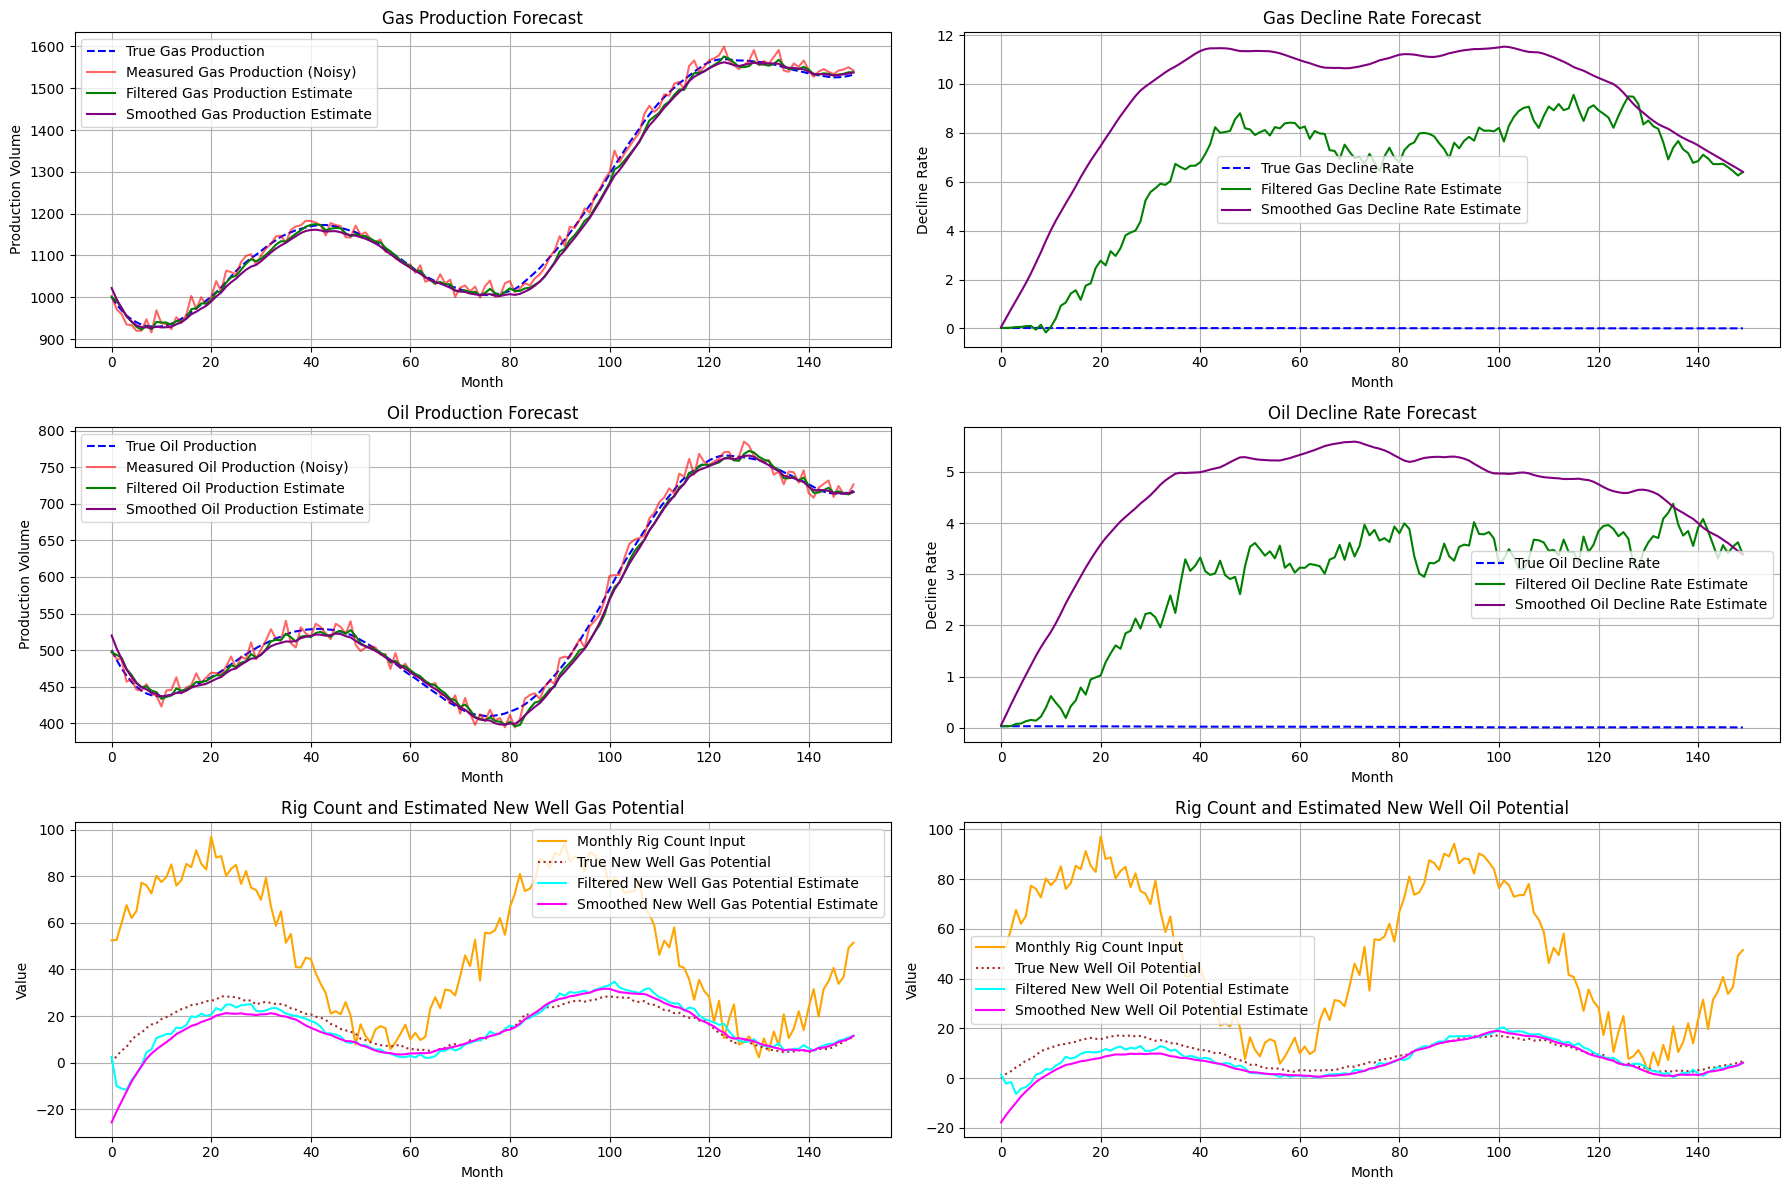

In [ ]:
import numpy as np
from pykalman import KalmanFilter
import matplotlib.pyplot as plt

def kalman_filter_advanced_production_forecast(gas_production_measurements, oil_production_measurements, rig_count_input):
    """
    Applies a Kalman Filter to forecast gas and oil production based on rig count,
    incorporating decline rates and correlation.

    Args:
        gas_production_measurements (np.array): Array of historical monthly gas production.
        oil_production_measurements (np.array): Array of historical monthly oil production.
        rig_count_input (np.array): Array of historical monthly rig counts (input control).

    Returns:
        tuple: A tuple containing:
            - filtered_state_means (np.array): Filtered estimates of the state variables.
            - filtered_state_covariances (np.array): Covariances of the filtered estimates.
            - smoothed_state_means (np.array): Smoothed estimates of the state variables.
            - smoothed_state_covariances (np.array): Covariances of the smoothed estimates.
    """

    n_timesteps = len(gas_production_measurements)
    if not (len(oil_production_measurements) == n_timesteps and len(rig_count_input) == n_timesteps):
        raise ValueError("All input arrays must have the same number of timesteps.")

    # --- 1. Define the State Variables ---
    # State vector (x_t):
    # [0] Gas_Production_t              (P_g)
    # [1] Gas_Decline_Rate_t            (D_g)
    # [2] Oil_Production_t              (P_o)
    # [3] Oil_Decline_Rate_t            (D_o)
    # [4] New_Well_Gas_Production_Potential_t (NWP_g) - represents new production added by rigs
    # [5] New_Well_Oil_Production_Potential_t (NWP_o) - represents new production added by rigs
    n_states = 6

    # --- 2. Transition Matrix (A) and Control-Input Matrix (B) ---
    # A describes x_t = A * x_{t-1} (without control input)
    # B describes the effect of u_t (rig_count) as B * u_t

    # Factors for decline rate persistence and new well potential decay
    gas_decline_rate_persistence = 0.98 # Closer to 1 means more constant decline rate
    oil_decline_rate_persistence = 0.98
    new_well_potential_decay = 0.90 # How quickly the *potential* of new wells diminishes if no new rigs

    transition_matrix = np.array([
        # P_g(t) = P_g(t-1) * (1 - D_g(t-1)) + NWP_g(t-1)
        [1, -1, 0, 0, 1, 0],
        # D_g(t) = D_g(t-1) * persistence
        [0, gas_decline_rate_persistence, 0, 0, 0, 0],
        # P_o(t) = P_o(t-1) * (1 - D_o(t-1)) + NWP_o(t-1)
        [0, 0, 1, -1, 0, 1],
        # D_o(t) = D_o(t-1) * persistence
        [0, 0, 0, oil_decline_rate_persistence, 0, 0],
        # NWP_g(t) = NWP_g(t-1) * decay (Rig count influence is via B*u)
        [0, 0, 0, 0, new_well_potential_decay, 0],
        # NWP_o(t) = NWP_o(t-1) * decay (Rig count influence is via B*u)
        [0, 0, 0, 0, 0, new_well_potential_decay]
    ])

    # Control-input matrix (B)
    # Rig count primarily affects the New Well Production Potential for both gas and oil.
    # rig_to_gas_potential_factor: How much one rig contributes to new gas production potential
    # rig_to_oil_potential_factor: How much one rig contributes to new oil production potential
    rig_to_gas_potential_factor = 0.05
    rig_to_oil_potential_factor = 0.03

    control_input_matrix = np.array([
        [0], # P_g
        [0], # D_g
        [0], # P_o
        [0], # D_o
        [rig_to_gas_potential_factor], # NWP_g is directly influenced by current rig count
        [rig_to_oil_potential_factor]  # NWP_o is directly influenced by current rig count
    ])

    # --- 3. Observation Model (C) ---
    # Observation vector (y_t): [Measured_Gas_Production_t, Measured_Oil_Production_t]
    n_observations = 2

    # Measured production is just the sum of existing production (with decline) and new well potential
    observation_matrix = np.array([
        [1, 0, 0, 0, 1, 0], # Measured Gas_Prod = P_g + NWP_g
        [0, 0, 1, 0, 0, 1]  # Measured Oil_Prod = P_o + NWP_o
    ])

    # --- 4. Noise Covariances ---
    # Process noise covariance (Q): Uncertainty in the state transition.
    # This matrix captures the correlations you mentioned.
    # For example, increased uncertainty in gas production might correlate with oil production.
    process_noise_covariance = np.diag([
        1.0,  # Gas_Production
        0.01, # Gas_Decline_Rate
        1.0,  # Oil_Production
        0.01, # Oil_Decline_Rate
        0.1,  # New_Well_Gas_Production_Potential
        0.1   # New_Well_Oil_Production_Potential
    ])

    # Let's add some off-diagonal terms for correlation between gas and oil production changes.
    # This matrix should be symmetric.
    # Assuming gas and oil production changes are positively correlated due to associated production.
    # Tune these values carefully.
    correlation_factor = 0.5 # Strength of correlation
    process_noise_covariance[0, 2] = correlation_factor * np.sqrt(process_noise_covariance[0,0] * process_noise_covariance[2,2]) # P_g with P_o
    process_noise_covariance[2, 0] = process_noise_covariance[0, 2] # Symmetric

    process_noise_covariance[4, 5] = correlation_factor * np.sqrt(process_noise_covariance[4,4] * process_noise_covariance[5,5]) # NWP_g with NWP_o
    process_noise_covariance[5, 4] = process_noise_covariance[4, 5] # Symmetric

    # Measurement noise covariance (R): Uncertainty in the measurements.
    measurement_noise_covariance = np.diag([
        5.0, # Measured Gas_Production (e.g., in thousands of cubic feet)
        5.0  # Measured Oil_Production (e.g., in barrels)
    ])

    # --- 5. Initialize State and Covariance ---
    # Initial state mean (x0): Best guess for the starting state.
    # These often come from initial observations or industry averages.
    initial_gas_prod = gas_production_measurements[0]
    initial_oil_prod = oil_production_measurements[0]
    # Initial decline rates are crucial; you might estimate them from early data or domain knowledge.
    initial_gas_decline_rate = 0.02 # e.g., 2% per month
    initial_oil_decline_rate = 0.03 # e.g., 3% per month
    # Initial new well potential proportional to initial rig count or zero if starting before significant drilling
    initial_new_well_gas_potential = rig_count_input[0] * rig_to_gas_potential_factor
    initial_new_well_oil_potential = rig_count_input[0] * rig_to_oil_potential_factor

    initial_state_mean = np.array([
        initial_gas_prod,
        initial_gas_decline_rate,
        initial_oil_prod,
        initial_oil_decline_rate,
        initial_new_well_gas_potential,
        initial_new_well_oil_potential
    ])

    # Initial state covariance (P0): Uncertainty in the initial state estimate.
    initial_state_covariance = np.diag([
        100.0, # Gas_Production (high uncertainty if initial guess is weak)
        0.001, # Gas_Decline_Rate (small uncertainty if you have a good initial estimate)
        100.0, # Oil_Production
        0.001, # Oil_Decline_Rate
        10.0,  # New_Well_Gas_Production_Potential
        10.0   # New_Well_Oil_Production_Potential
    ])

    # --- 6. Prepare Observations and Control Inputs ---
    observations = np.stack((gas_production_measurements, oil_production_measurements), axis=1)
    control_inputs = rig_count_input.reshape(-1, 1) # Needs to be 2D array (n_timesteps, n_controls)

    # Calculate time-varying transition offsets from control input
    # The control_input_matrix (B) should multiply the control_inputs (u_t)
    # B is (n_states, n_controls), u_t is (n_timesteps, n_controls)
    # The result should be (n_timesteps, n_states)
    transition_offsets = np.dot(control_inputs, control_input_matrix.T) # (n_timesteps, n_states)

    # --- 7. Create and Run the Kalman Filter ---
    kf = KalmanFilter(
        transition_matrices=transition_matrix,
        observation_matrices=observation_matrix,
        transition_covariance=process_noise_covariance,
        observation_covariance=measurement_noise_covariance,
        initial_state_mean=initial_state_mean,
        initial_state_covariance=initial_state_covariance,
        transition_offsets=transition_offsets # Pass the calculated offsets here
    )

    # The pykalman library implicitly handles the B*u term when `n_dim_control` is set
    # and `control_input` is passed to the filter/smooth methods.
    # However, the `transition_matrices` should be dynamic if state variables
    # (like production) are multiplied by other state variables (like decline rate).
    # For this specific non-linearity (P_t = P_{t-1} * (1 - D_{t-1})),
    # a standard KalmanFilter (which assumes linearity) will be an approximation.
    # An Extended Kalman Filter (EKF) or Unscented Kalman Filter (UKF) would be more appropriate
    # for truly non-linear state transitions.
    # For demonstration, we'll keep `transition_matrix` static, acknowledging its approximation aspects.

    # Filter the data
    (filtered_state_means, filtered_state_covariances) = kf.filter(observations)

    # Smooth the data
    (smoothed_state_means, smoothed_state_covariances) = kf.smooth(observations)

    return filtered_state_means, filtered_state_covariances, smoothed_state_means, smoothed_state_covariances


if __name__ == "__main__":
    # --- Example Usage with Synthetic Data ---
    np.random.seed(42) # for reproducibility

    n_months = 150

    # Simulate true underlying states
    true_gas_production = np.zeros(n_months)
    true_gas_decline_rate = np.zeros(n_months)
    true_oil_production = np.zeros(n_months)
    true_oil_decline_rate = np.zeros(n_months)
    true_new_well_gas_potential = np.zeros(n_months)
    true_new_well_oil_potential = np.zeros(n_months)

    # Simulate Rig Count - input control
    rig_count_base = 50
    rig_count_amplitude = 40
    rig_count_noise = 5
    true_rig_count = rig_count_base + rig_count_amplitude * np.sin(np.linspace(0, 4 * np.pi, n_months)) + np.random.normal(0, rig_count_noise, n_months)
    true_rig_count[true_rig_count < 0] = 0 # Rig count cannot be negative

    # Initial true values
    true_gas_production[0] = 1000 # Initial production for gas
    true_gas_decline_rate[0] = 0.02 # 2% per month
    true_oil_production[0] = 500  # Initial production for oil
    true_oil_decline_rate[0] = 0.03 # 3% per month

    # Simulate dynamics with decline and rig effects
    rig_to_gas_factor_sim = 0.05
    rig_to_oil_factor_sim = 0.03
    new_well_decay_sim = 0.85 # Higher decay for simulation to see impact clearer

    for i in range(1, n_months):
        # Decline existing production
        true_gas_production[i] = true_gas_production[i-1] * (1 - true_gas_decline_rate[i-1])
        true_oil_production[i] = true_oil_production[i-1] * (1 - true_oil_decline_rate[i-1])

        # New well potential from rig count
        # This is where the acceleration-like effect of rig count comes in.
        # It's added to production, then decays if not sustained by new rigs.
        true_new_well_gas_potential[i] = new_well_decay_sim * true_new_well_gas_potential[i-1] + rig_to_gas_factor_sim * true_rig_count[i-1] + np.random.normal(0, 0.5)
        true_new_well_oil_potential[i] = new_well_decay_sim * true_new_well_oil_potential[i-1] + rig_to_oil_factor_sim * true_rig_count[i-1] + np.random.normal(0, 0.3)

        # Add new well potential to total production
        true_gas_production[i] += true_new_well_gas_potential[i]
        true_oil_production[i] += true_new_well_oil_potential[i]

        # Decline rates can also fluctuate slightly
        true_gas_decline_rate[i] = true_gas_decline_rate[i-1] * 0.99 + np.random.normal(0, 0.0005)
        true_oil_decline_rate[i] = true_oil_decline_rate[i-1] * 0.99 + np.random.normal(0, 0.0007)

        # Ensure decline rates remain positive and within reasonable bounds
        true_gas_decline_rate[i] = np.clip(true_gas_decline_rate[i], 0.005, 0.05)
        true_oil_decline_rate[i] = np.clip(true_oil_decline_rate[i], 0.005, 0.08)

    # Simulate noisy measurements (observations for the Kalman Filter)
    measurement_noise_std_gas = 15
    measurement_noise_std_oil = 10
    measured_gas_production = true_gas_production + np.random.normal(0, measurement_noise_std_gas, n_months)
    measured_oil_production = true_oil_production + np.random.normal(0, measurement_noise_std_oil, n_months)

    # Apply the Kalman Filter
    filtered_means, filtered_covs, smoothed_means, smoothed_covs = kalman_filter_advanced_production_forecast(
        measured_gas_production,
        measured_oil_production,
        true_rig_count
    )

    # --- Plotting Results ---
    plt.figure(figsize=(18, 12))

    # Gas Production
    plt.subplot(3, 2, 1)
    plt.plot(true_gas_production, label='True Gas Production', color='blue', linestyle='--')
    plt.plot(measured_gas_production, label='Measured Gas Production (Noisy)', color='red', alpha=0.6)
    plt.plot(filtered_means[:, 0], label='Filtered Gas Production Estimate', color='green')
    plt.plot(smoothed_means[:, 0], label='Smoothed Gas Production Estimate', color='purple')
    plt.title('Gas Production Forecast')
    plt.xlabel('Month')
    plt.ylabel('Production Volume')
    plt.legend()
    plt.grid(True)

    # Gas Decline Rate
    plt.subplot(3, 2, 2)
    plt.plot(true_gas_decline_rate, label='True Gas Decline Rate', color='blue', linestyle='--')
    plt.plot(filtered_means[:, 1], label='Filtered Gas Decline Rate Estimate', color='green')
    plt.plot(smoothed_means[:, 1], label='Smoothed Gas Decline Rate Estimate', color='purple')
    plt.title('Gas Decline Rate Forecast')
    plt.xlabel('Month')
    plt.ylabel('Decline Rate')
    plt.legend()
    plt.grid(True)

    # Oil Production
    plt.subplot(3, 2, 3)
    plt.plot(true_oil_production, label='True Oil Production', color='blue', linestyle='--')
    plt.plot(measured_oil_production, label='Measured Oil Production (Noisy)', color='red', alpha=0.6)
    plt.plot(filtered_means[:, 2], label='Filtered Oil Production Estimate', color='green')
    plt.plot(smoothed_means[:, 2], label='Smoothed Oil Production Estimate', color='purple')
    plt.title('Oil Production Forecast')
    plt.xlabel('Month')
    plt.ylabel('Production Volume')
    plt.legend()
    plt.grid(True)

    # Oil Decline Rate
    plt.subplot(3, 2, 4)
    plt.plot(true_oil_decline_rate, label='True Oil Decline Rate', color='blue', linestyle='--')
    plt.plot(filtered_means[:, 3], label='Filtered Oil Decline Rate Estimate', color='green')
    plt.plot(smoothed_means[:, 3], label='Smoothed Oil Decline Rate Estimate', color='purple')
    plt.title('Oil Decline Rate Forecast')
    plt.xlabel('Month')
    plt.ylabel('Decline Rate')
    plt.legend()
    plt.grid(True)

    # Rig Count and New Well Production Potential (Gas)
    plt.subplot(3, 2, 5)
    plt.plot(true_rig_count, label='Monthly Rig Count Input', color='orange')
    plt.plot(true_new_well_gas_potential, label='True New Well Gas Potential', color='brown', linestyle=':')
    plt.plot(filtered_means[:, 4], label='Filtered New Well Gas Potential Estimate', color='cyan')
    plt.plot(smoothed_means[:, 4], label='Smoothed New Well Gas Potential Estimate', color='magenta')
    plt.title('Rig Count and Estimated New Well Gas Potential')
    plt.xlabel('Month')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)

    # Rig Count and New Well Production Potential (Oil)
    plt.subplot(3, 2, 6)
    plt.plot(true_rig_count, label='Monthly Rig Count Input', color='orange')
    plt.plot(true_new_well_oil_potential, label='True New Well Oil Potential', color='brown', linestyle=':')
    plt.plot(filtered_means[:, 5], label='Filtered New Well Oil Potential Estimate', color='cyan')
    plt.plot(smoothed_means[:, 5], label='Smoothed New Well Oil Potential Estimate', color='magenta')
    plt.title('Rig Count and Estimated New Well Oil Potential')
    plt.xlabel('Month')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()